Note: akiec mapped to malignant (borderline — flagged in output).
Device: cuda
Metadata CSV : /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image dir    : /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Columns : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
Total rows : 10015
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
Using image col='image_id', label col='dx'
Image files indexed: 10015
Rows with found images : 10015  |  missing : 0
After label mapping : 10015 rows
three_class
benign            7804
malignant         1954
non-neoplastic     257
Name: count, dtype: int64

Computing ITA for skin tone classification...
  ITA computed for 500/10015 images
  ITA computed for 1000/10015 images
  ITA co

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Extracting light-skin features...
Light features: (3139, 768)
Extracting dark-skin features...
Dark features: (6717, 768)

=== MAD Risk Score (New Formula) — Part A ===
nc/Ng            : 0.8094 (80.9%)
n_minority_train : 5437
mu_cosine        : 0.8667
Stage            : MAD-G
MAD Risk Score   : 0.0155

=== PART A: Single-point DRO Validation ===
  seed=42: benign_acc=0.805 demo_auc=0.715 min_wt=0.0000 collapse=True
  seed=0: benign_acc=0.855 demo_auc=0.695 min_wt=0.0000 collapse=True
  seed=1: benign_acc=0.768 demo_auc=0.731 min_wt=0.0000 collapse=True
  seed=7: benign_acc=0.708 demo_auc=0.738 min_wt=0.0000 collapse=True
  seed=99: benign_acc=0.817 demo_auc=0.731 min_wt=0.0000 collapse=True

Part A collapse rate: 5/5
Mean benign acc: 0.791 ± 0.056

=== PART B: nc/Ng Sweep ===

nc/Ng=0.049 | n_min=26 | mu=0.8684 | stage=MAD-G | risk=0.0399
  seed=42: benign_acc=0.551 min_wt=0.0000 collapse=True
  seed=0: benign_acc=0.580 min_wt=0.0000 collapse=True
  seed=1: benign_acc=0.6

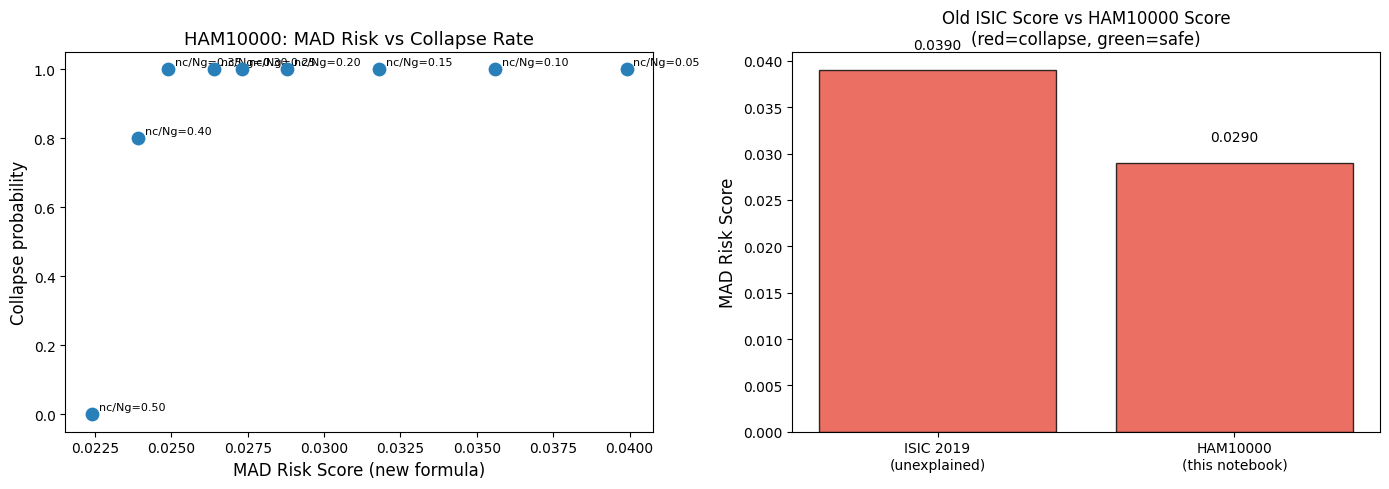

Figure saved: ham10000_sweep_curve.png

=== LaTeX TABLE ROWS ===
Dataset & Modality & nc/Ng & n_min & $\mu_{\cos}$ & MAD Risk & Stage & Collapse Rate & Benign Acc \\
\hline
HAM10000 (Part A) & Dermoscopy & 0.809 & 5437 & 0.8667 & 0.0155 & MAD-G & 5/5 & 0.791 $\pm$ 0.056 \\
HAM10000 sweep nc/Ng=0.049 & Dermoscopy & 0.049 & 26 & 0.8684 & 0.0399 & MAD-G & 5/5 & 0.614 $\pm$ 0.048 \\
HAM10000 sweep nc/Ng=0.101 & Dermoscopy & 0.101 & 56 & 0.8559 & 0.0356 & MAD-G & 5/5 & 0.616 $\pm$ 0.041 \\
HAM10000 sweep nc/Ng=0.150 & Dermoscopy & 0.150 & 88 & 0.8571 & 0.0318 & MAD-G & 5/5 & 0.598 $\pm$ 0.062 \\
HAM10000 sweep nc/Ng=0.200 & Dermoscopy & 0.200 & 125 & 0.8609 & 0.0288 & MAD-G & 5/5 & 0.595 $\pm$ 0.088 \\
HAM10000 sweep nc/Ng=0.250 & Dermoscopy & 0.250 & 167 & 0.8599 & 0.0273 & MAD-G & 5/5 & 0.630 $\pm$ 0.059 \\
HAM10000 sweep nc/Ng=0.300 & Dermoscopy & 0.300 & 214 & 0.8582 & 0.0264 & MAD-G & 5/5 & 0.733 $\pm$ 0.022 \\
HAM10000 sweep nc/Ng=0.350 & Dermoscopy & 0.350 & 269 & 0.8606 & 0.0249 & M

In [3]:
# ============================================================
# HAM10000 — Dermoscopy Validation + ISIC Contradiction Resolution
# CLIP ViT-L/14, dermoscopic modality
# GPU T4, Internet ON. ~90 min.
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np, pandas as pd, os, math, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────
BASE_SEED      = 42
SEEDS          = [42, 0, 1, 7, 99]
DRO_ETA        = 0.1
N_EPOCHS       = 5
BATCH_SIZE     = 32
ADAMW_LR       = 1e-4
ADAMW_WD       = 1e-4
N_CLASSES      = 3
FEAT_DIM       = 768
N_GROUPS       = 6
COLLAPSE_THR   = 0.01
MAD_I_GATE     = 0.02

ITA_DARK_MAX   = 10.0
ITA_LIGHT_MIN  = 28.0

LABEL_MAP = {
    'nv':    'benign',
    'bkl':   'benign',
    'mel':   'malignant',
    'bcc':   'malignant',
    'akiec': 'malignant',
    'df':    'non-neoplastic',
    'vasc':  'non-neoplastic'
}
print("Note: akiec mapped to malignant (borderline — flagged in output).")

ISIC_NC_NG   = 0.190
ISIC_MAD_OLD = 0.039
ISIC_COLLAPSE = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Formula functions ──────────────────────────────────────────
def mean_pairwise_cosine(embeddings):
    if len(embeddings) < 2:
        return 0.0
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    sim    = normed @ normed.T
    n      = len(embeddings)
    upper  = sim[np.triu_indices(n, k=1)]
    return float(np.mean(upper))

def compute_mad_risk(mu_cosine, n_minority_train, nc_ng):
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    score = (1.0 - mu_cosine) / math.log(1.0 + n_minority_train)
    return 'MAD-G', score

def compute_ita(img_path):
    try:
        img = Image.open(img_path).convert('LAB')
        w, h = img.size
        cx, cy = w // 2, h // 2
        region = img.crop((cx-20, cy-20, cx+20, cy+20))
        pixels = np.array(region)
        L_mean = pixels[:,:,0].mean() / 255.0 * 100.0
        b_mean = (pixels[:,:,2].mean() - 128.0)
        ita = math.degrees(math.atan2(L_mean - 50.0, b_mean))
        return ita
    except:
        return float('nan')

# ── Dataset discovery ─────────────────────────────────────────
_ham_csv = None
_ham_img_dir = None

for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f == 'HAM10000_metadata.csv':
            _ham_csv = os.path.join(_root, _f)
            _ham_img_dir = _root
            break
    if _ham_csv:
        break

if _ham_csv is None:
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        for _f in _files:
            if (_f.endswith('.csv')
                    and 'metadata' in _f.lower()
                    and 'hmnist' not in _f.lower()):
                _ham_csv = os.path.join(_root, _f)
                _ham_img_dir = _root
                break
        if _ham_csv:
            break

print(f"Metadata CSV : {_ham_csv}")
print(f"Image dir    : {_ham_img_dir}")
assert _ham_csv is not None, "HAM10000_metadata.csv not found. Add the HAM10000 dataset to this notebook."

# ── Load metadata ─────────────────────────────────────────────
df = pd.read_csv(_ham_csv)
print(f"Columns : {list(df.columns)}")
print(f"Total rows : {len(df)}")
print(df.head(3))

img_col   = 'image_id' if 'image_id' in df.columns else df.columns[0]
label_col = 'dx'       if 'dx'       in df.columns else df.columns[1]
print(f"Using image col='{img_col}', label col='{label_col}'")

# ── Image file index ──────────────────────────────────────────
image_files = {}
for _r, _, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f.lower().endswith(('.jpg', '.jpeg', '.png')):
            stem = os.path.splitext(_f)[0]
            image_files[stem] = os.path.join(_r, _f)
print(f"Image files indexed: {len(image_files)}")

df['local_path'] = df[img_col].map(image_files)
missing = df['local_path'].isna().sum()
print(f"Rows with found images : {len(df) - missing}  |  missing : {missing}")
df = df[df['local_path'].notna()].copy()

assert len(df) > 0, (
    "No images matched. Check that HAM10000_images_part_1 and "
    "HAM10000_images_part_2 folders are present in the dataset."
)

# ── 3-class mapping ───────────────────────────────────────────
df['three_class'] = df[label_col].map(LABEL_MAP)
df = df[df['three_class'].notna()].copy()
print(f"After label mapping : {len(df)} rows")
print(df['three_class'].value_counts())

# ── ITA-based skin tone ───────────────────────────────────────
print("\nComputing ITA for skin tone classification...")
itas = []
for i, row in df.iterrows():
    ita = compute_ita(row['local_path'])
    itas.append(ita)
    if len(itas) % 500 == 0:
        print(f"  ITA computed for {len(itas)}/{len(df)} images")

df['ita'] = itas
df = df[df['ita'].notna() & ~np.isnan(df['ita'])].copy()

df['skin_group'] = df['ita'].apply(
    lambda x: 'light' if x > ITA_LIGHT_MIN else ('dark' if x <= ITA_DARK_MAX else 'medium')
)
print(f"\nSkin group distribution (ITA-based):")
print(df['skin_group'].value_counts())
print(f"ITA: mean={df['ita'].mean():.1f}, std={df['ita'].std():.1f}")

df_main  = df[df['skin_group'].isin(['light','dark'])].copy()
dark_df  = df_main[df_main['skin_group']=='dark'].copy()
light_df = df_main[df_main['skin_group']=='light'].copy()

print(f"\nLight-skin samples : {len(light_df)}")
print(f"Dark-skin samples  : {len(dark_df)}")
assert len(light_df) > 0, "No light-skin samples found after ITA filtering."
assert len(dark_df)  > 0, "No dark-skin samples found after ITA filtering."

n_dark_total  = len(dark_df)
n_dark_benign = (dark_df['three_class']=='benign').sum()
nc_ng = n_dark_benign / n_dark_total if n_dark_total > 0 else 0.0

print(f"\n=== HAM10000 Dataset Statistics ===")
print(f"Total (light+dark) : {len(df_main)}")
print(f"Light-skin         : {len(light_df)}")
print(f"Dark-skin total    : {n_dark_total}")
print(f"Dark-skin benign   : {n_dark_benign}")
print(f"nc/Ng              : {nc_ng:.4f} ({nc_ng*100:.1f}%)")

# ── Load CLIP ─────────────────────────────────────────────────
print("\nLoading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")

le = LabelEncoder()
le.fit(['benign', 'malignant', 'non-neoplastic'])
BENIGN_IDX = int(list(le.classes_).index('benign'))
MINORITY_G = 1 * N_CLASSES + BENIGN_IDX

# ── FIX: handle BaseModelOutputWithPooling from some transformers versions ──
def extract_feats(dataframe, skin_label_int, batch_size=64):
    feats, labels, groups = [], [], []
    paths  = dataframe['local_path'].tolist()
    lbls   = dataframe['three_class'].tolist()
    lmap   = {c: i for i, c in enumerate(le.classes_)}
    for i in range(0, len(paths), batch_size):
        bp = paths[i:i+batch_size]
        bl = lbls[i:i+batch_size]
        imgs, valid = [], []
        for j, p in enumerate(bp):
            try:
                imgs.append(Image.open(p).convert('RGB'))
                valid.append(j)
            except:
                continue
        if not imgs:
            continue
        inputs = clip_proc(images=imgs, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            out = clip_model.get_image_features(**inputs)
            # FIX: some transformers versions return a ModelOutput object, not a tensor
            if hasattr(out, 'pooler_output'):
                out = out.pooler_output
            out = out / out.norm(dim=-1, keepdim=True)
        feats.extend(out.cpu().numpy())
        for j in valid:
            lbl = bl[j]
            labels.append(lmap.get(lbl, 0))
            groups.append(skin_label_int * N_CLASSES + lmap.get(lbl, 0))
    return np.array(feats), np.array(labels), np.array(groups)

print("Extracting light-skin features...")
light_feats, light_labels, light_groups = extract_feats(light_df, 0)
print(f"Light features: {light_feats.shape}")

print("Extracting dark-skin features...")
dark_feats, dark_labels, dark_groups = extract_feats(dark_df, 1)
print(f"Dark features: {dark_feats.shape}")

assert light_feats.ndim == 2 and light_feats.shape[0] > 0, "Light feature extraction produced no results."
assert dark_feats.ndim  == 2 and dark_feats.shape[0]  > 0, "Dark feature extraction produced no results."

# ── MAD Risk Score ────────────────────────────────────────────
dark_benign_mask  = (dark_labels == BENIGN_IDX)
dark_benign_feats = dark_feats[dark_benign_mask]
n_minority_train  = int(dark_benign_mask.sum())
mu_cosine         = mean_pairwise_cosine(dark_benign_feats)
stage, mad_risk   = compute_mad_risk(mu_cosine, n_minority_train, nc_ng)

print(f"\n=== MAD Risk Score (New Formula) — Part A ===")
print(f"nc/Ng            : {nc_ng:.4f} ({nc_ng*100:.1f}%)")
print(f"n_minority_train : {n_minority_train}")
print(f"mu_cosine        : {mu_cosine:.4f}")
print(f"Stage            : {stage}")
print(f"MAD Risk Score   : {'N/A (MAD-I)' if mad_risk is None else f'{mad_risk:.4f}'}")

# ── DRO classifier ────────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(FEAT_DIM, N_CLASSES)
    def forward(self, x):
        return self.fc(x)

def run_dro(tr_feats, tr_labels, tr_groups, te_feats, te_labels, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    X = torch.tensor(tr_feats, dtype=torch.float32).to(device)
    y = torch.tensor(tr_labels, dtype=torch.long).to(device)
    g = torch.tensor(tr_groups, dtype=torch.long).to(device)
    model   = LinearProbe().to(device)
    opt     = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    q = torch.ones(N_GROUPS).to(device) / N_GROUPS
    for epoch in range(N_EPOCHS):
        model.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(X), BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]
            xb, yb, gb = X[idx], y[idx], g[idx]
            logits = model(xb)
            losses = loss_fn(logits, yb)
            group_losses = torch.zeros(N_GROUPS).to(device)
            for grp in range(N_GROUPS):
                mask = (gb == grp)
                if mask.sum() > 0:
                    group_losses[grp] = losses[mask].mean()
            weighted = (q * group_losses).sum()
            opt.zero_grad()
            weighted.backward()
            opt.step()
            with torch.no_grad():
                q *= torch.exp(DRO_ETA * group_losses.detach())
                q /= q.sum()
    final_min_wt = q[MINORITY_G].item()
    model.eval()
    Xt = torch.tensor(te_feats, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(Xt)
        preds  = logits.argmax(dim=1).cpu().numpy()
        probs  = torch.softmax(logits.cpu(), dim=1).numpy()
    bm    = (te_labels == BENIGN_IDX)
    b_acc = accuracy_score(te_labels[bm], preds[bm]) if bm.sum() > 0 else 0.0
    try:
        d_auc = roc_auc_score(te_labels, probs, multi_class='ovr', average='macro')
    except:
        d_auc = float('nan')
    collapse = final_min_wt < COLLAPSE_THR
    return b_acc, d_auc, final_min_wt, collapse

# ── PART A: Single-point validation ──────────────────────────
print("\n=== PART A: Single-point DRO Validation ===")
results_a = []
out_csv_a = 'ham10000_validation_results.csv'

for seed in SEEDS:
    b_acc, d_auc, min_wt, collapse = run_dro(
        light_feats, light_labels, light_groups,
        dark_feats, dark_labels, seed
    )
    row = {
        'part': 'A_single_point',
        'nc_ng': round(nc_ng, 4),
        'n_minority_train': n_minority_train,
        'stage': stage,
        'mad_risk': round(mad_risk, 4) if mad_risk is not None else None,
        'mu_cosine': round(mu_cosine, 4),
        'seed': seed,
        'benign_acc': round(b_acc, 4),
        'demo_auc': round(d_auc, 4),
        'min_wt': round(min_wt, 4),
        'collapse': collapse
    }
    results_a.append(row)
    print(f"  seed={seed}: benign_acc={b_acc:.3f} demo_auc={d_auc:.3f} "
          f"min_wt={min_wt:.4f} collapse={collapse}")
    pd.DataFrame(results_a).to_csv(out_csv_a, index=False)

df_a = pd.DataFrame(results_a)
cr_a = df_a['collapse'].sum()
print(f"\nPart A collapse rate: {int(cr_a)}/5")
print(f"Mean benign acc: {df_a['benign_acc'].mean():.3f} ± {df_a['benign_acc'].std():.3f}")

# ── PART B: nc/Ng sweep ───────────────────────────────────────
print("\n=== PART B: nc/Ng Sweep ===")
TARGET_NG_SWEEP = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

np.random.seed(BASE_SEED)
dark_benign_all        = dark_feats[dark_benign_mask]
dark_benign_labels_all = dark_labels[dark_benign_mask]
dark_other_mask        = ~dark_benign_mask
dark_other_all         = dark_feats[dark_other_mask]
dark_other_labels_all  = dark_labels[dark_other_mask]

results_b = []
out_csv_b = 'ham10000_sweep_results.csv'

for target_ng in TARGET_NG_SWEEP:
    n_dark_other    = min(500, len(dark_other_all))
    other_idx       = np.random.choice(len(dark_other_all), n_dark_other, replace=False)
    n_benign_needed = int(round(target_ng * n_dark_other / (1 - target_ng + 1e-9)))
    n_benign_needed = min(n_benign_needed, len(dark_benign_all))
    benign_idx      = np.random.choice(len(dark_benign_all), n_benign_needed, replace=False)

    pool_other_f  = dark_other_all[other_idx]
    pool_other_l  = dark_other_labels_all[other_idx]
    pool_benign_f = dark_benign_all[benign_idx]
    pool_benign_l = dark_benign_labels_all[benign_idx]

    actual_ng   = n_benign_needed / (n_dark_other + n_benign_needed)
    n_min_train = n_benign_needed
    mu_cos      = mean_pairwise_cosine(pool_benign_f)
    stg, risk   = compute_mad_risk(mu_cos, n_min_train, actual_ng)

    print(f"\nnc/Ng={actual_ng:.3f} | n_min={n_min_train} | mu={mu_cos:.4f} | "
          f"stage={stg} | risk={'N/A' if risk is None else f'{risk:.4f}'}")

    dark_pool_f = np.vstack([pool_other_f, pool_benign_f])
    dark_pool_l = np.concatenate([pool_other_l, pool_benign_l])
    dark_pool_g = np.array([1 * N_CLASSES + l for l in dark_pool_l])
    tr_f = np.vstack([light_feats, dark_pool_f])
    tr_l = np.concatenate([light_labels, dark_pool_l])
    tr_g = np.concatenate([light_groups, dark_pool_g])

    for seed in SEEDS:
        b_acc, d_auc, min_wt, collapse = run_dro(
            tr_f, tr_l, tr_g, dark_feats, dark_labels, seed
        )
        row = {
            'part': 'B_sweep',
            'nc_ng': round(actual_ng, 4),
            'n_minority_train': n_min_train,
            'stage': stg,
            'mad_risk': round(risk, 4) if risk is not None else None,
            'mu_cosine': round(mu_cos, 4),
            'seed': seed,
            'benign_acc': round(b_acc, 4),
            'demo_auc': round(d_auc, 4),
            'min_wt': round(min_wt, 4),
            'collapse': collapse
        }
        results_b.append(row)
        print(f"  seed={seed}: benign_acc={b_acc:.3f} min_wt={min_wt:.4f} collapse={collapse}")
    pd.DataFrame(results_b).to_csv(out_csv_b, index=False)
    print(f"  Saved {out_csv_b}")

df_b = pd.DataFrame(results_b)

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ham_summary = df_b[df_b['stage']=='MAD-G'].groupby('nc_ng').agg(
    mad_risk=('mad_risk', 'first'),
    collapse_rate=('collapse', 'mean'),
    benign_mean=('benign_acc', 'mean')
).reset_index()

axes[0].scatter(ham_summary['mad_risk'], ham_summary['collapse_rate'],
                s=80, color='#2980b9', label='HAM10000 (dermoscopy)', zorder=5)
axes[0].set_xlabel('MAD Risk Score (new formula)', fontsize=12)
axes[0].set_ylabel('Collapse probability', fontsize=12)
axes[0].set_title('HAM10000: MAD Risk vs Collapse Rate', fontsize=13)
axes[0].set_ylim(-0.05, 1.05)
for _, row in ham_summary.iterrows():
    axes[0].annotate(f"nc/Ng={row['nc_ng']:.2f}",
                     (row['mad_risk'], row['collapse_rate']),
                     textcoords='offset points', xytext=(5,3), fontsize=8)

datasets  = ['ISIC 2019\n(unexplained)', 'HAM10000\n(this notebook)']
ham_score = float(ham_summary['mad_risk'].mean()) if len(ham_summary) > 0 else 0.0
scores    = [ISIC_MAD_OLD, ham_score]
collapse  = [1.0, ham_summary['collapse_rate'].mean() if len(ham_summary) > 0 else 0.0]
colors    = ['#e74c3c' if c > 0.5 else '#27ae60' for c in collapse]
bars = axes[1].bar(datasets, scores, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('MAD Risk Score', fontsize=12)
axes[1].set_title('Old ISIC Score vs HAM10000 Score\n(red=collapse, green=safe)', fontsize=12)
for bar, s in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{s:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('ham10000_sweep_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ham10000_sweep_curve.png")

# ── LaTeX table rows ──────────────────────────────────────────
print("\n=== LaTeX TABLE ROWS ===")
print("Dataset & Modality & nc/Ng & n_min & $\\mu_{\\cos}$ & MAD Risk & Stage & Collapse Rate & Benign Acc \\\\")
print("\\hline")
scr_a = f"{mad_risk:.4f}" if mad_risk is not None else 'N/A (MAD-I)'
print(f"HAM10000 (Part A) & Dermoscopy & {nc_ng:.3f} & {n_minority_train} & "
      f"{mu_cosine:.4f} & {scr_a} & {stage} & {int(cr_a)}/5 & "
      f"{df_a['benign_acc'].mean():.3f} $\\pm$ {df_a['benign_acc'].std():.3f} \\\\")
for _, row in df_b.groupby('nc_ng').first().reset_index().iterrows():
    cr      = df_b[df_b['nc_ng']==row['nc_ng']]['collapse'].sum()
    ba_mean = df_b[df_b['nc_ng']==row['nc_ng']]['benign_acc'].mean()
    ba_std  = df_b[df_b['nc_ng']==row['nc_ng']]['benign_acc'].std()
    scr     = f"{row['mad_risk']:.4f}" if row['mad_risk'] is not None else 'N/A'
    print(f"HAM10000 sweep nc/Ng={row['nc_ng']:.3f} & Dermoscopy & {row['nc_ng']:.3f} & "
          f"{int(row['n_minority_train'])} & {row['mu_cosine']:.4f} & {scr} & "
          f"{row['stage']} & {int(cr)}/5 & {ba_mean:.3f} $\\pm$ {ba_std:.3f} \\\\")

# ── Interpretation flags ──────────────────────────────────────
print("\n=== INTERPRETATION FLAGS ===")
print(f"HAM10000 Part A (single-point):")
print(f"  nc/Ng={nc_ng:.3f}, n_min={n_minority_train}, mu={mu_cosine:.4f}")
print(f"  MAD stage={stage}, score={'N/A' if mad_risk is None else f'{mad_risk:.4f}'}")
print(f"  Collapse rate: {int(cr_a)}/5")
if int(cr_a) >= 3:
    print("PART A: Collapse confirmed on HAM10000.")
    print("  → IF new formula predicted collapse: confirms generalization to dermoscopy.")
else:
    print("PART A: No collapse on HAM10000.")
    print("  → Safe regime confirmed. Compare to ISIC (which collapsed).")
    print("  → Implies nc/Ng or n_min differs enough from ISIC to explain divergence.")
print(f"\nKEY QUESTION: Does HAM10000 sweep identify a threshold that explains the ISIC failure?")
print(f"ISIC reference  : nc/Ng={ISIC_NC_NG:.3f}, old MAD={ISIC_MAD_OLD:.4f}, collapsed=5/5")
print(f"HAM10000 Part A : nc/Ng={nc_ng:.3f}, new MAD={'N/A' if mad_risk is None else f'{mad_risk:.4f}'}, collapsed={int(cr_a)}/5")
print("\nLIMITATION: ITA computed from image center — may misclassify images with non-skin")
print("background. Consider validating on HAM10000 subset with known FST labels if available.")

# ── Per-seed table ────────────────────────────────────────────
print("\n=== PART A PER-SEED TABLE ===")
print(f"{'seed':>6} {'stage':>6} {'mad_risk':>10} {'benign_acc':>12} {'demo_auc':>10} {'min_wt':>8} {'collapse':>9}")
for _, row in df_a.iterrows():
    sc = f"{row['mad_risk']:.4f}" if row['mad_risk'] is not None else '   N/A  '
    print(f"{int(row['seed']):>6} {row['stage']:>6} {sc:>10} "
          f"{row['benign_acc']:>12.3f} {row['demo_auc']:>10.4f} "
          f"{row['min_wt']:>8.4f} {str(row['collapse']):>9}")

print("\n✓ Complete.")
print("Files: ham10000_validation_results.csv, ham10000_sweep_results.csv, ham10000_sweep_curve.png")